(ch_dimensionality)=
# Dimensionality Reduction

## Why high dimensions are hard, or: the curse of dimensionality

In data science, we often work with datasets that contain many variables, or **dimensions**, for each observation. Just as a reminder: any feature or property of our data can be counted as a dimension. I guess you can easily imagine tabular data that is described by 5, 10, or 20 different columns. That would then be 5-, 10-, or 20-dimensional data. But we can easily make it much more extreme by simply taking image data. Say we have images of 1000 x 1000 pixels, then every pixel is a dimension [^pixel] so that we end up with one million dimensions!

Here, we are not so much concerned with data storage or raw performance issues. In other words: the main question in this section is **not** how to compress files efficiently or how to save memory on a disk. Instead, the real problem is that high-dimensional data becomes increasingly difficult to **understand, compare, visualize, and analyze** in a meaningful way.

This collection of difficulties is often summarized under the term **curse of dimensionality**. The phrase sounds dramatic, but it is actually very fitting. Once data lives in many dimensions, several things that feel natural and intuitive in 2D or 3D begin to break down.

### 1) Growing feature spaces: too much space, too little data
A first problem is simply that higher-dimensional spaces grow extremely fast. If we want to "cover" a one-dimensional line with 100 positions, that is easy. If we want the same resolution in two dimensions, we already need 100 × 100 = 10,000 positions. In three dimensions, that becomes 1,000,000. Imagine, for instance, a dataset with just three features: age, weight, and height as indicated in {numref}`fig_dimensionality_reduction01`. And from there on, things escalate quickly. This means that with every added dimension, the available data becomes relatively more sparse. Even datasets that look very large to us may in fact be tiny compared to the size of the feature space they occupy.

This sparsity has serious consequences. It becomes harder to estimate densities, harder to detect reliable local structure, and harder to learn general patterns without overfitting. Many methods that work well in low dimensions quietly rely on the assumption that nearby observations tell us something useful about each other. In very high dimensions, that assumption becomes much weaker.

So one way to think about the curse of dimensionality is:

> As the number of dimensions grows, the available data becomes increasingly insufficient to meaningfully cover the space.

```{figure} ../images/fig_curse_of_dimensionality_01.png
:name: fig_dimensionality_reduction01

In many cases, we will work with data that has more than just 2 or 3 relevant features (or: dimensions). While age, weight, and height might all be of interest when we analyze a dataset of people, it is not very likely that this will be sufficient to reveal very interesting patterns. We can easily plot 2 or 3 features (see (a)). But what do we do if we want to add additional features, maybe even *many* additional features?
The *curse of dimensionality* can be understood by imagining that we have to fully explore a feature space. 2D and 3D are relatively straightforward, but when we have to cover a much higher dimensional space, we simply need far too many datapoints to *cover* this space reasonably well (see (b)).
```

### 2) Distance measures become less informative

A second, very important problem concerns **distance**. Many methods in data science rely on distances, either directly or indirectly. We have already seen this for **clustering** algorithms such as K-means or DBSCAN in {numref}`ch_clustering`, both of which are computed based on the distances between datapoints. Later in this course, we will see many more examples of where distance functions will be essential, in particular for many machine-learning models.

In 2D or 3D, distances often behave in a very intuitive way. Some points are clearly close, others are clearly far away. In high dimensions, this starts to change.

A well-known effect is that distances tend to become more and more similar {cite}`marimont_nearest_1979, chavez_searching_2001`. The difference between the nearest and the farthest neighbor often shrinks relative to the overall scale of the distances. In other words, the geometry becomes less contrasted. Points are still not literally all at the same distance—but the distinction between "close" and "far" becomes much weaker.

This is a serious problem for any method that depends on meaningful neighborhood structure.

### A small experiment: Euclidean distances in higher dimensions

Let us make this more concrete. In the following code, we generate points uniformly at random in spaces of different dimensionality and compute many random pairwise Euclidean distances.

[^pixel]: For RGB colored images, it is actually even 3 dimensions per pixel, one for each color.

In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

# Set the ggplot style (optional)
plt.style.use("ggplot")

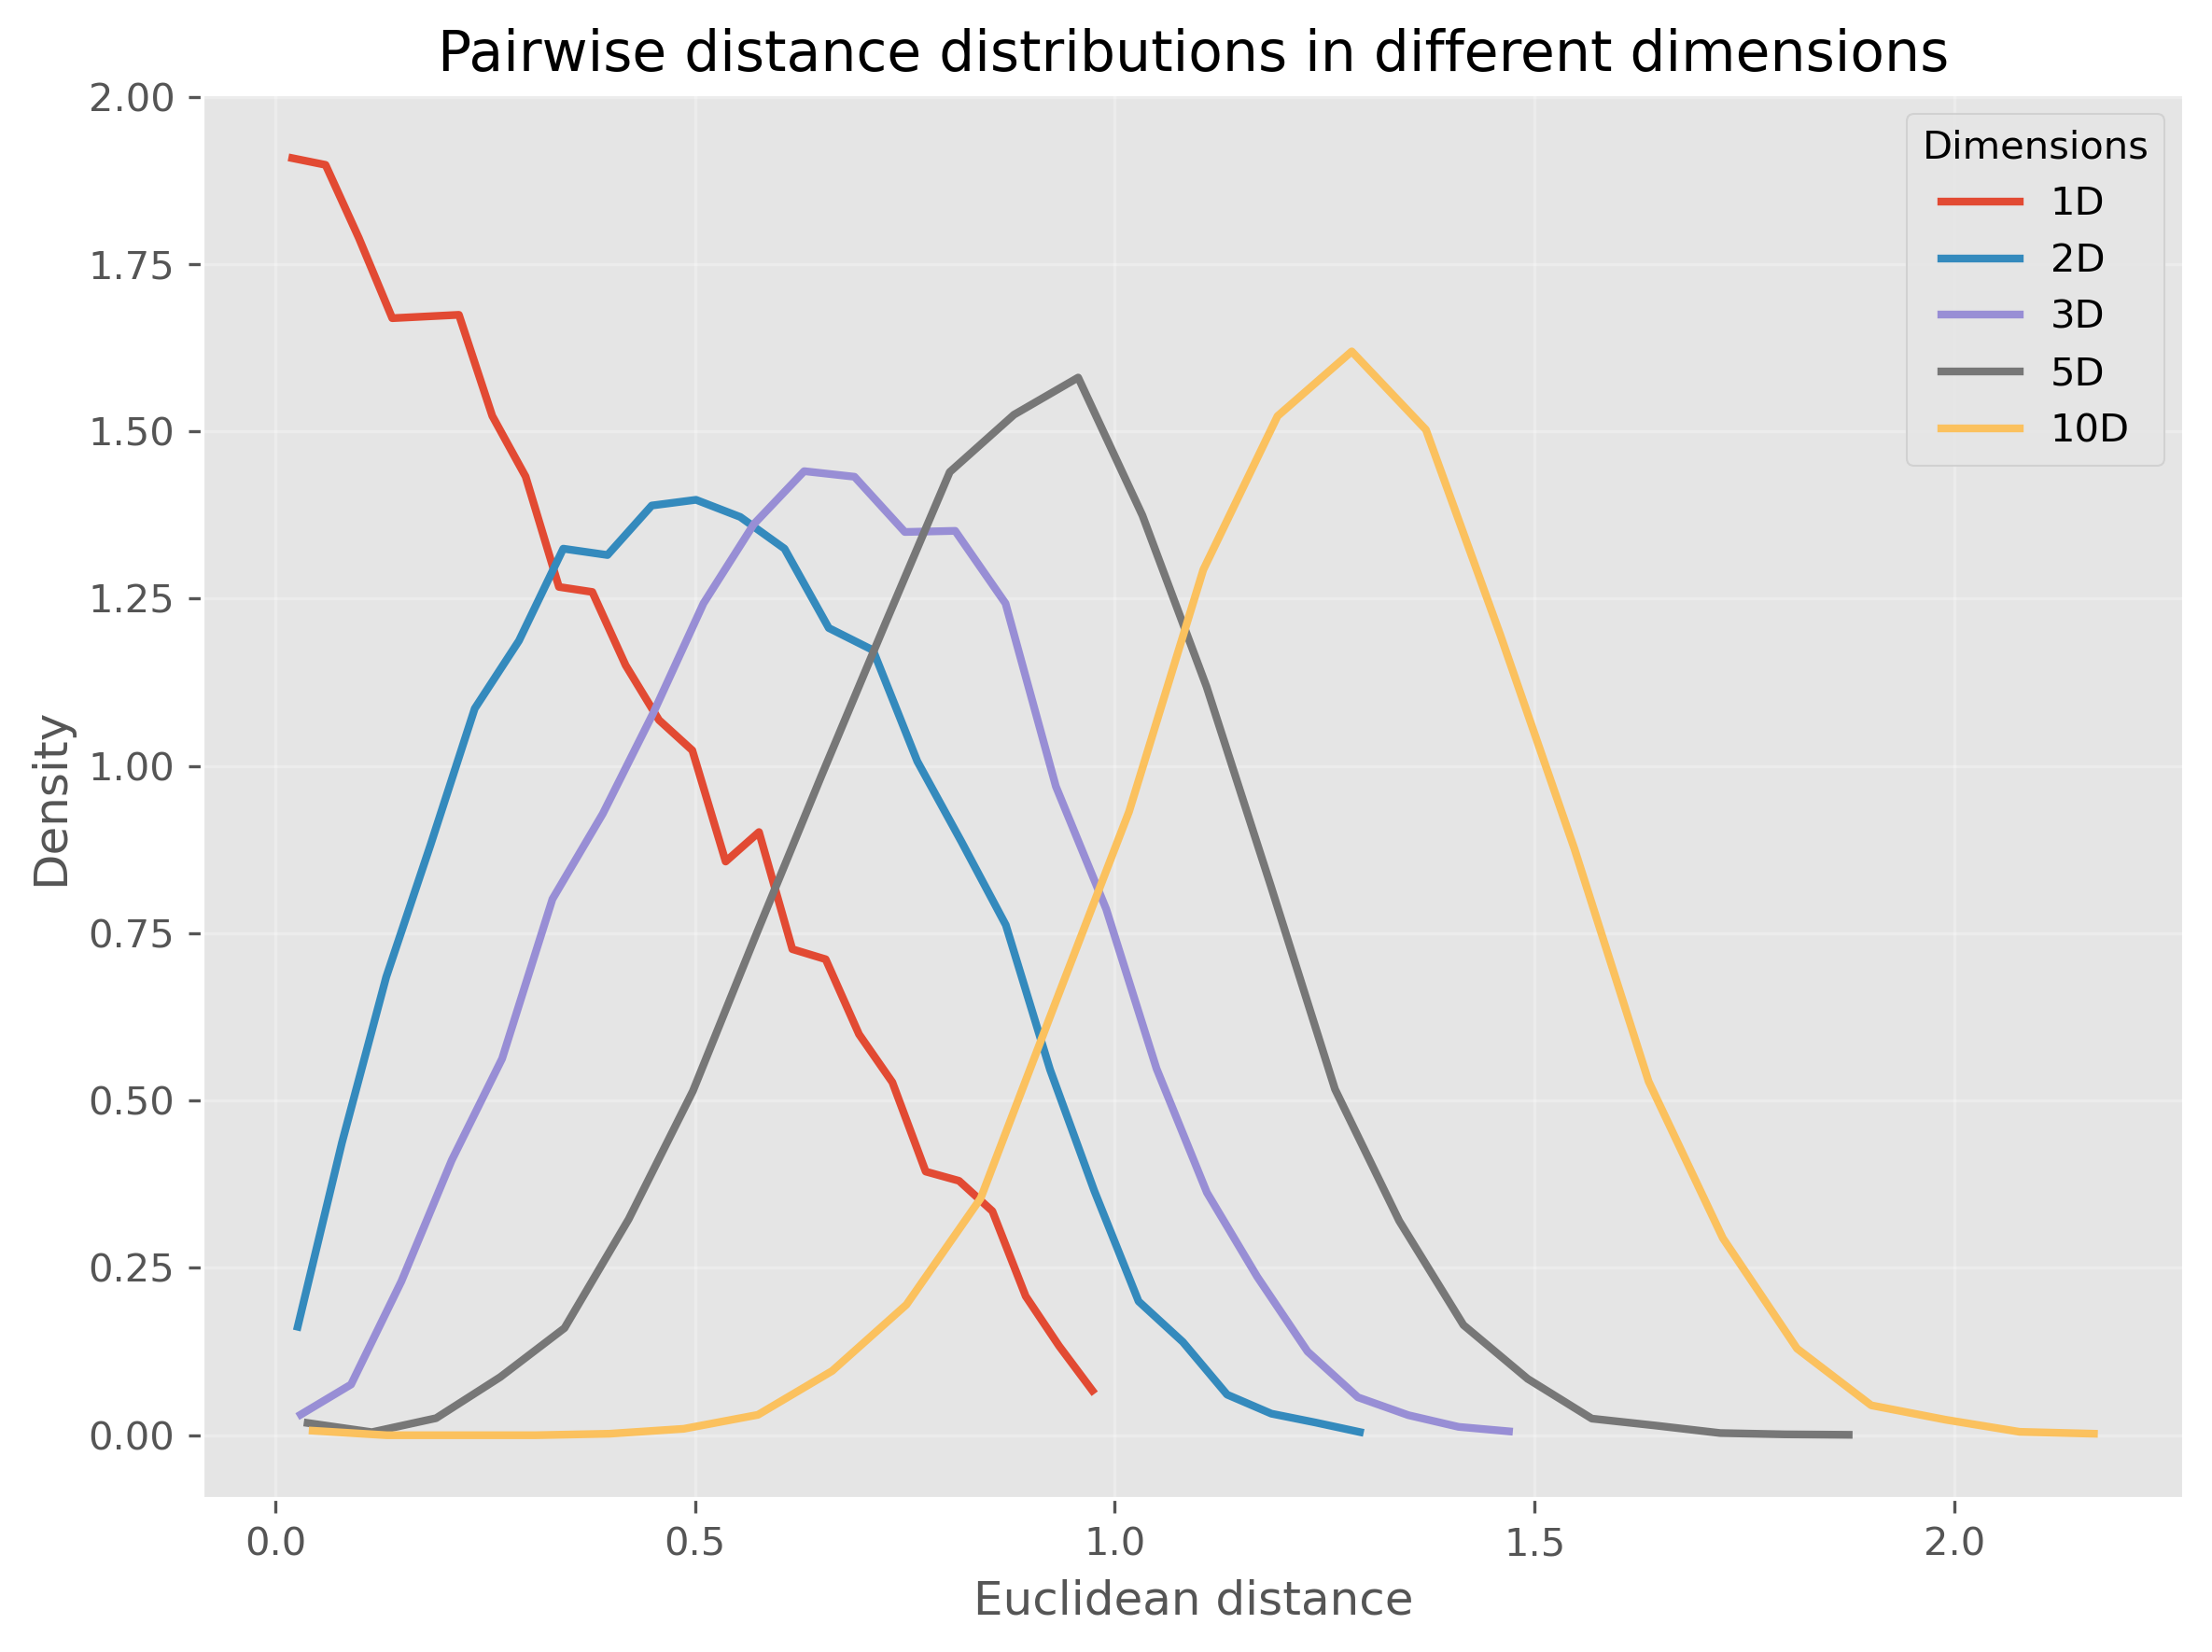

In [2]:
rng = np.random.default_rng(seed=101010)

dimensions = [1, 2, 3, 5, 10]
n_points = 1000
n_pairs = 20_000

fig, ax = plt.subplots(figsize=(8, 6), dpi=300)

for dim in dimensions:
    # random points in [0,1]^dim
    X = rng.uniform(0, 1, size=(n_points, dim))

    # choose random pairs of points
    idx1 = rng.integers(0, n_points, size=n_pairs)
    idx2 = rng.integers(0, n_points, size=n_pairs)

    distances = np.linalg.norm(X[idx1] - X[idx2], axis=1)

    # histogram as line
    counts, bins = np.histogram(distances, bins=25, density=True)
    bin_centers = 0.5 * (bins[:-1] + bins[1:])

    ax.plot(
        bin_centers, counts,
        linewidth=2, label=f"{dim}D"
    )

ax.set_xlabel("Euclidean distance")
ax.set_ylabel("Density")
ax.set_title("Pairwise distance distributions in different dimensions")
ax.legend(title="Dimensions")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Or, we can even make this much more extreme and go up to 1000 dimensions:

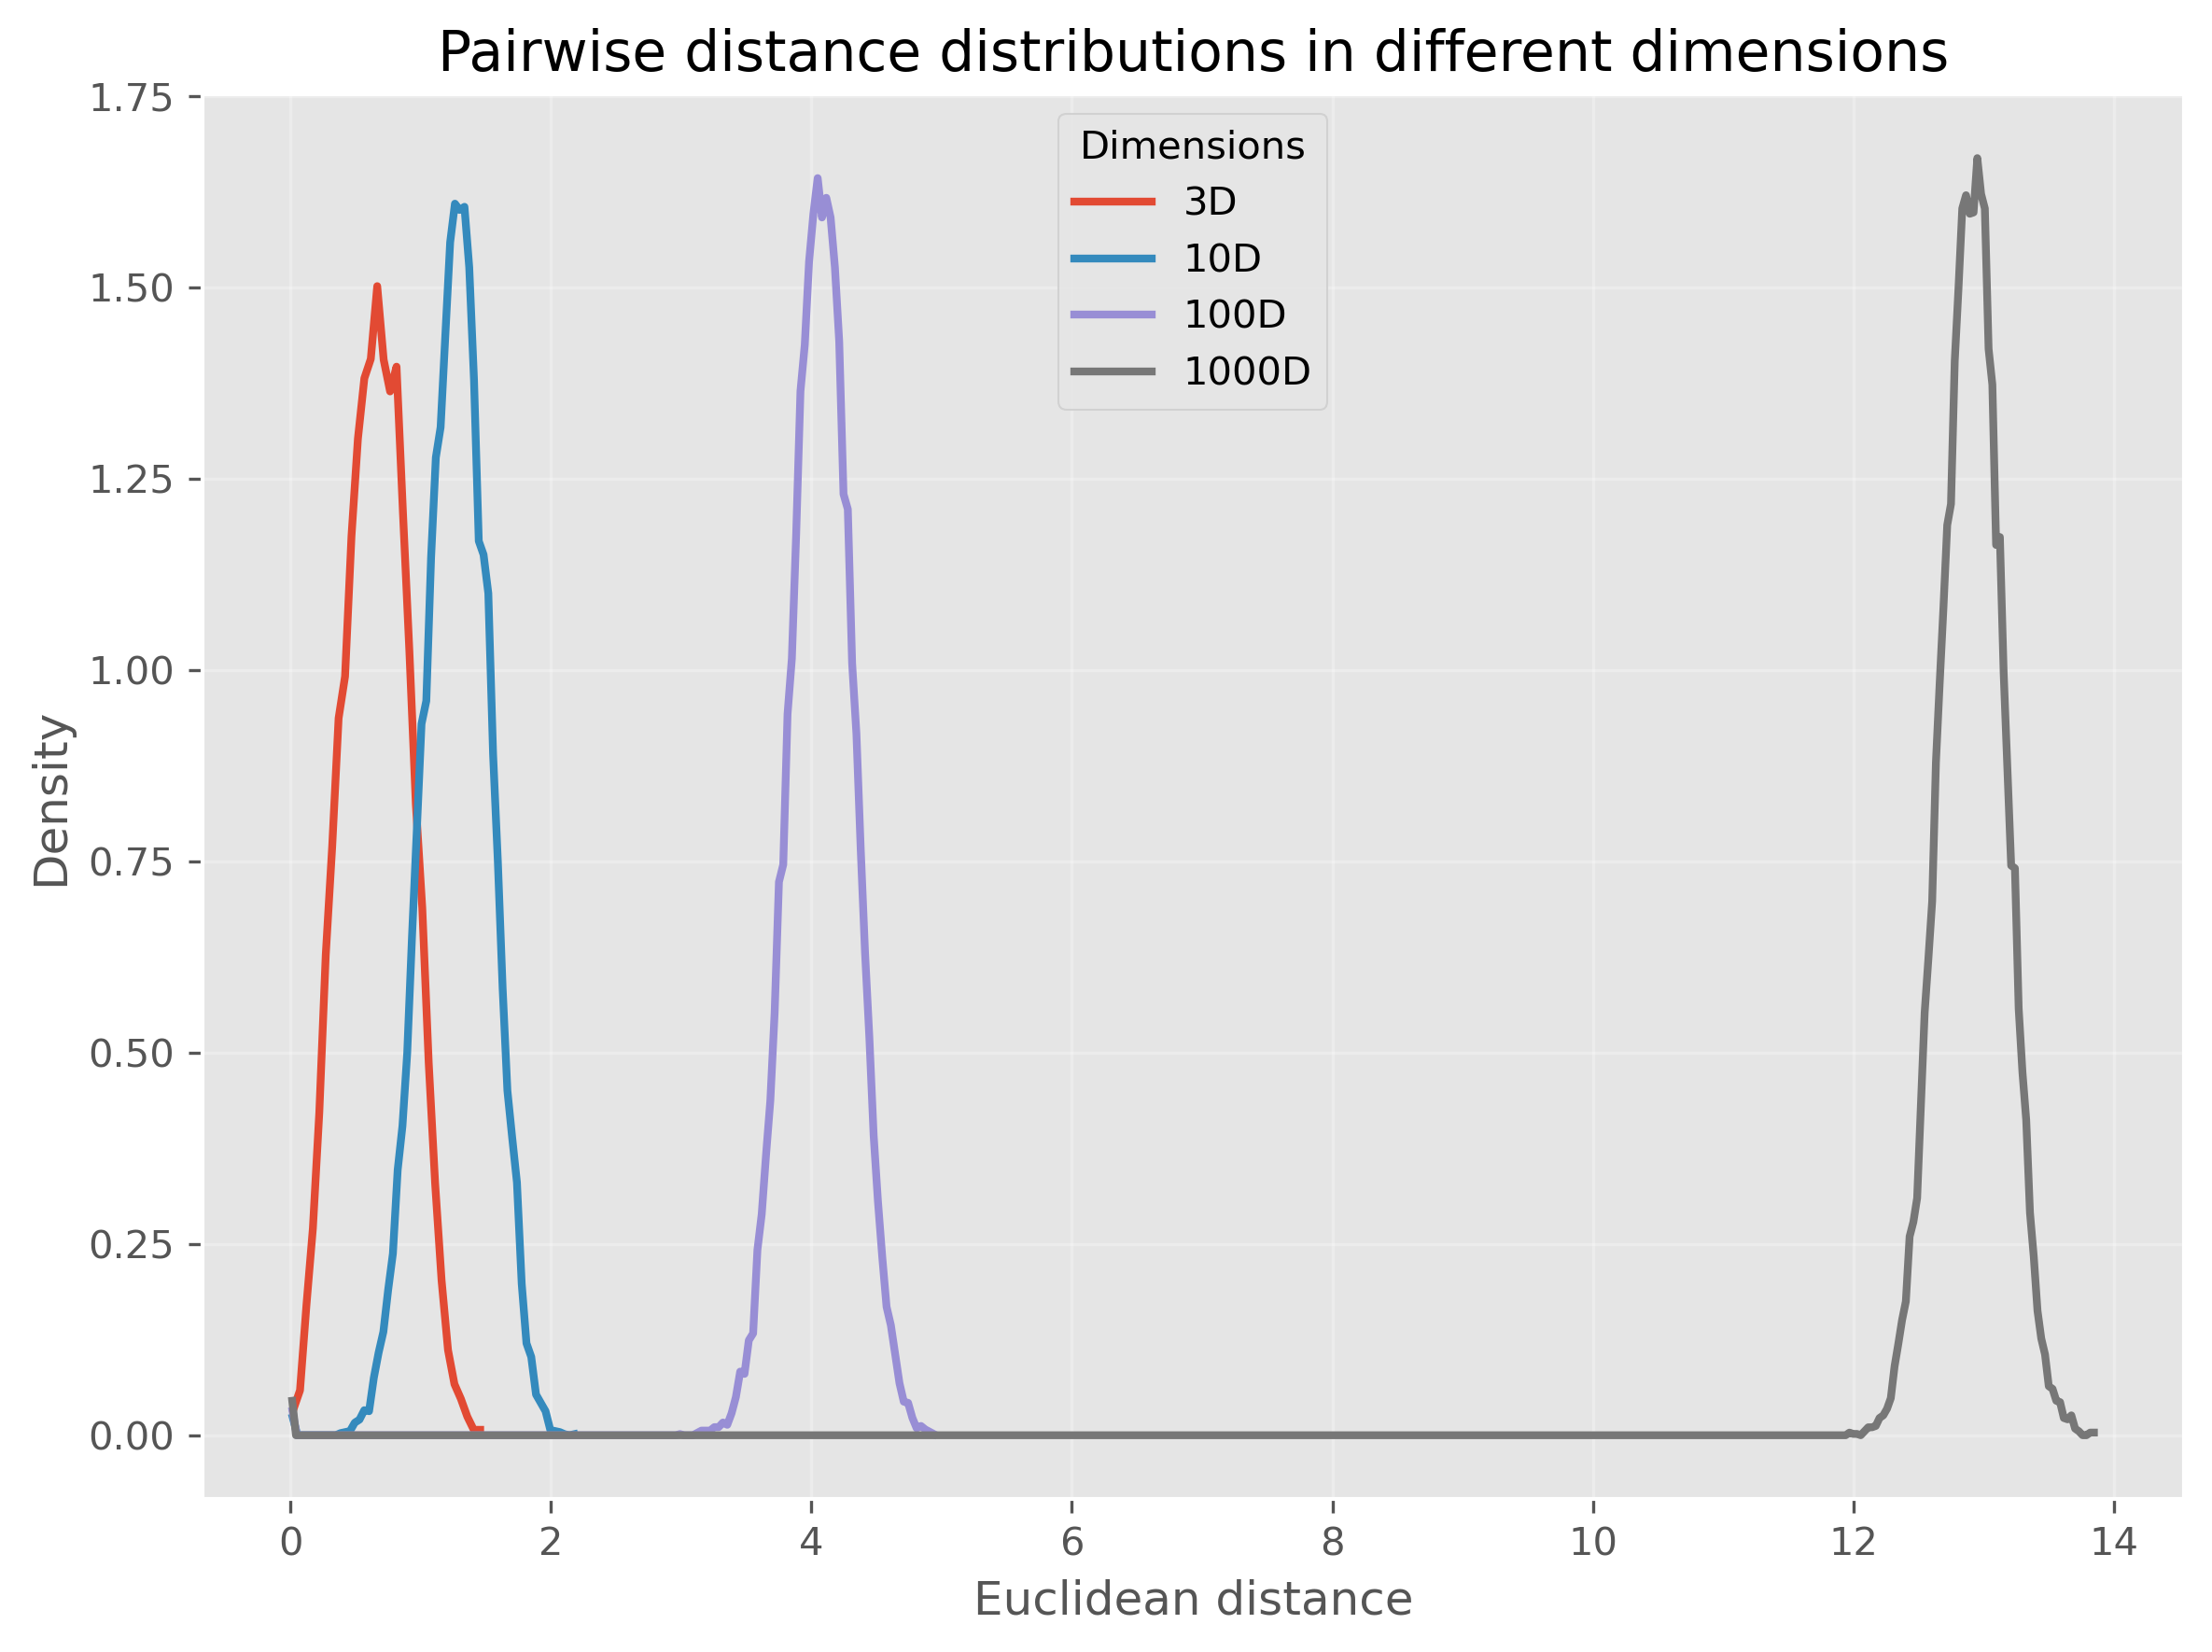

In [3]:
rng = np.random.default_rng(seed=101010)

dimensions = [3, 10, 100, 1000]
n_points = 1000
n_pairs = 20_000

fig, ax = plt.subplots(figsize=(8, 6), dpi=300)

for dim in dimensions:
    # random points in [0,1]^dim
    X = rng.uniform(0, 1, size=(n_points, dim))

    # choose random pairs of points
    idx1 = rng.integers(0, n_points, size=n_pairs)
    idx2 = rng.integers(0, n_points, size=n_pairs)

    distances = np.linalg.norm(X[idx1] - X[idx2], axis=1)

    # histogram as line
    counts, bins = np.histogram(distances, bins=15*int(np.ceil(dim**0.5)), density=True)
    bin_centers = 0.5 * (bins[:-1] + bins[1:])

    ax.plot(
        bin_centers, counts,
        linewidth=2, label=f"{dim}D"
    )

ax.set_xlabel("Euclidean distance")
ax.set_ylabel("Density")
ax.set_title("Pairwise distance distributions in different dimensions")
ax.legend(title="Dimensions")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

We see that for very high-dimensional data, nearly all computed distances are in a very narrow range (at least in our example when using Euclidean distances). This is one reason why computing "nearest" neighbors for high-dimensional data can quickly become complicated.

So, this second perspective on the curse of dimensionality could be phrased as:
> In high-dimensional spaces, common distance measures often become less discriminative.

### 3. Visualization becomes impossible very quickly

A third problem is more obvious, but still important: we cannot directly visualize high-dimensional data.

Two dimensions are easy to plot. Three dimensions are still manageable, although already harder to interpret. Beyond that, we quickly run out of intuitive visual representations. We can encode a few extra dimensions using color, marker size, or symbol type, but this only gets us a little further.

This means that for many real datasets, we are effectively blind unless we reduce the data to fewer dimensions first.

## The Role of Dimensionality Reduction

**Dimensionality reduction** techniques address these challenges by transforming high-dimensional data into a lower-dimensional representation that retains the most informative aspects. This can be viewed as a form of data compression that simplifies large datasets, making them easier to explore and analyze.

Dimensionality reduction is often required for later data visualizations, as we will see later in this chapter. But it can also be applied to enhance the performance of analytical models by reducing the computational burden and minimizing the risk of overfitting.

Luckily, we as (future) data scientists can apply a wide variety of powerful techniques to reduce the number of our feature dimensions. In this chapter, we will focus on a few common techniques which fall into different categories of algorithms as shown in {numref}`fig_dimensionality_reduction_techniques`. There are, however, plenty of other methods that we cannot cover here, see for instance {cite}`anowar2021conceptual` or {cite}`wang2021dimensionreduction`.

Before we start looking at the different methods, a brief warning: In nearly all cases, dimensionality reduction comes with a **trade-off between reduction of dimensions and information loss**. No matter which method we use to reduce 20-dimensional data to 2-dimensional data, some information will be lost in the process.

```{figure} ../images/fig_dimensionality_reduction_techniques.png
:name: fig_dimensionality_reduction_techniques

There are many different approaches to reducing the number of feature dimensions in data. **Feature selection** techniques aim at picking a subset of original features without transformation. **Feature extraction** techniques transform original features into a lower-dimensional space while capturing important information. Two important categories for such extraction processes are *projection-based* and *manifold-learning*, and in each category, we can find numerous, often very different, algorithms, a few of which are listed in this figure.
```

### Brief excursion: Feature Selection

A variant of dimensionality reduction is **feature selection**, which involves identifying and removing less important features for a specific task. Common methods include:

- **High Correlation Filter**: Remove one of each pair of highly correlated features to reduce redundancy.
- **Low Variance Filter**: Drop features whose values vary little across samples, as they contribute minimal information.
- **Missing Value Threshold**: Exclude features with excessive missing data to maintain dataset quality.
- **Feature Importance from Models**: Use algorithms like Random Forests or Gradient Boosting to rank and select features based on predictive power.

Feature selection is easy to interpret, because we keep actual input variables, and is often fast to compute. However, it typically achieves only modest dimensionality reduction, and identifying the right subset can require substantial domain knowledge. Therefore, we will here focus on **feature extraction** methods.

## Feature Extraction 1: Projection Methods

**Feature extraction** transforms original features into a new set of variables that capture the essence of the data in fewer dimensions. Projection methods, one of the most widely used extraction techniques, can be linear or non-linear:

### Linear Projections
- **Principal Component Analysis (PCA)**: Reduces dimensionality by transforming features into a new coordinate system, where the greatest variance by any projection of the data comes to lie on the first coordinate (called the first principal component), the second greatest variance on the second coordinate, and so on.
- **Linear Discriminant Analysis (LDA)**: Identifies directions that maximize class separability, making it ideal for supervised dimensionality reduction when class labels are available.

### Non-linear Projections
- **Kernel PCA**:  Extends PCA by applying the kernel trick to project data into a high-dimensional feature space before performing PCA, capturing non-linear relationships.
- **Multidimensional Scaling (MDS)** and **Isomap**: Preserve pairwise distances or geodesic distances on a manifold, respectively, enabling more flexible embeddings.
These projection methods can be highly effective for pattern recognition and machine learning tasks where the intrinsic dimensionality of the data is lower than the number of measured variables. They are particularly valuable when the goal is to simplify the data without losing critical information, facilitating faster and more efficient processing.

Projection methods can dramatically reduce dimensionality with minimal loss of structure, improving both visualization and downstream model performance.

### PCA (Principal Component Analysis)

Principal Component Analysis (PCA) is a cornerstone technique in dimensionality reduction, used extensively to simplify the complexity inherent in multi-dimensional data. This simplification aids in improving data interpretability, visualizations, and can even enhance the performance of machine learning algorithms by eliminating noise and redundancy. Below we detail the mechanisms of PCA and its practical application.

#### Concept

PCA systematically transforms the original correlated features into a new set of uncorrelated features, called principal components, ordered so that the first few retain most of the variation present in all of the original dimensions.

**Key steps in PCA:**

1. **Standardization**:

   - **Purpose**: PCA is affected by the scale of the features, as features with larger scales dominate the variance. Thus, standardizing the data (giving each feature zero mean and unit variance) ensures that each feature contributes equally.

   - **Method**:

     Each feature $x_i$ of the dataset is transformed as follows:

     $$x_i' = \frac{x_i − \mu_i}{\sigma_i}$$

     where $\mu_i$ is the mean and $\sigma_i$ is the standard deviation of the feature $x_i$.

2. **Covariance Matrix Computation**:

   - **Purpose**: The covariance matrix captures the pairwise covariances of features and reflects how changes in one feature correspond with changes in another.

   - **Method**:

     $$
     \Sigma  = \frac{1}{n-1} \left( X - \bar{X} \right)^T \left( X - \bar{X} \right)
     $$

     where $X$ is the feature matrix and $\bar{X}$ is the matrix of feature means.

3. **Eigenvalue Decomposition**:

   - **Purpose**: Decomposing the covariance matrix to extract its eigenvalues and eigenvectors identifies the new axes (principal components) that maximize the variance of the data when projected onto them.

   - **Method**:
     Solve the equation $\Sigma v = \lambda v$, where $\lambda$ represents the eigenvalues, and $v$ represents the corresponding eigenvectors. The eigenvectors define the directions of the new space, and the eigenvalues define their magnitude, indicating the amount of variance carried in each principal component.

4. **Selection of Principal Components**:

   - **Criteria**: Principal components are selected based on the magnitude of their eigenvalues in descending order. Components with the highest eigenvalues are chosen because they capture the most variance of the data set.
   - **Outcome**: The first few principal components often capture the majority of the variation, allowing for a significant reduction in dimensionality without substantial loss of information.

#### Practical Example with Python

We'll create a 2D dataset and apply PCA to reduce it to 1D. First, we'll generate a synthetic dataset.

In [4]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

#### Generating Synthetic Data

Let's create a dataset of 2 features with a clear linear relationship.

In [5]:
# Generating a synthetic 2D dataset
np.random.seed(0)
X = np.random.multivariate_normal(mean=[0, 0], cov=[[1, 0.8], [0.8, 1]], size=200)

# Standardizing the dataset
scaler = StandardScaler()
X_std = scaler.fit_transform(X)

#### Applying PCA

We will then standardize this data and apply PCA to reduce its dimensionality.
To inspect the results, we will use a simple scatter plot visualization.

In [6]:
# Applying PCA to reduce dimensionality from 2D to 1D
pca = PCA(n_components=1)
X_pca = pca.fit_transform(X_std)
print(X_pca.shape)

(200, 1)


PCA was here used to reduce the data from two dimensions to one.
As explained further above, PCA searches projections that maximize the variance. 
Here it found the following eigenvector that defines this projection:

In [7]:
pca.components_

array([[0.70710678, 0.70710678]])

The underlying computation, however, is not depending on our choice of `n_components`. So we can also decide to compute more PCA dimensions than we later want to use, for instance for visualization purposes.
The upper limit is the number of input dimensions, which in our simple example here is 2.

In [8]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_std)

pca.components_

array([[ 0.70710678,  0.70710678],
       [ 0.70710678, -0.70710678]])

These two vectors are orthogonal eigenvectors and we can also plot them to show which directions in our original 2-dimensional space were selected by PCA for the projection.

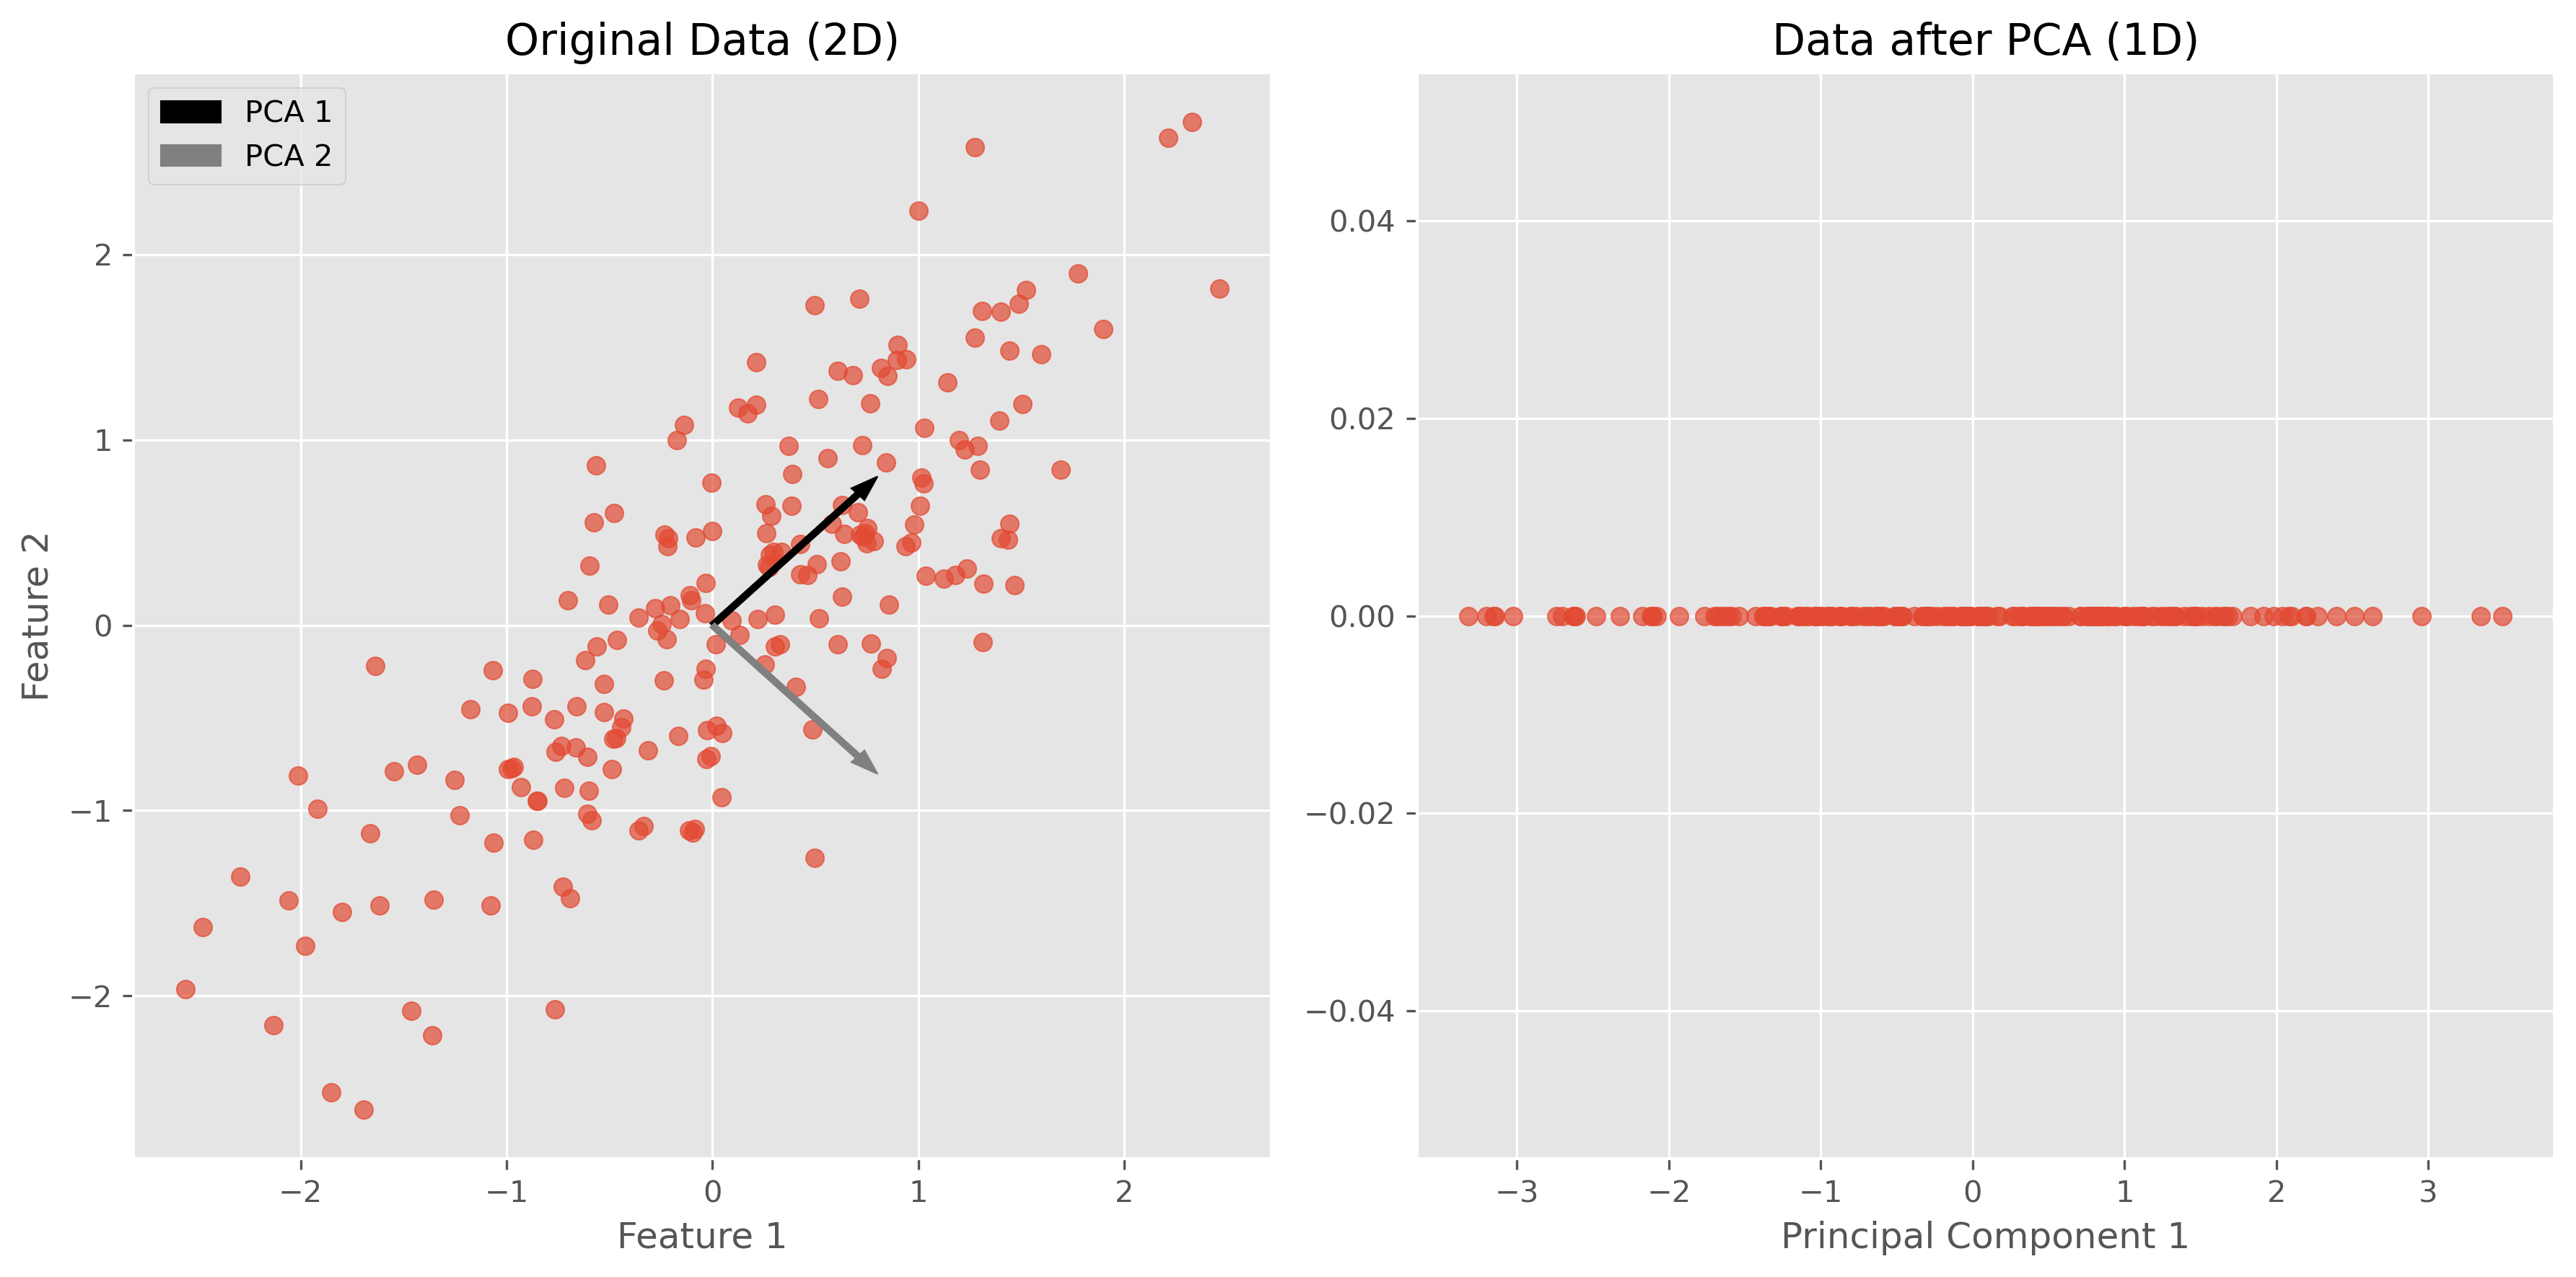

In [9]:
# Plotting the original data and the principal component
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6), dpi=300)

# Original Data (before PCA)
ax1.scatter(X[:, 0], X[:, 1], alpha=0.7)
ax1.arrow(0, 0, pca.components_[0, 0], pca.components_[0, 1], width = 0.03, color="black", label="PCA 1")
ax1.arrow(0, 0, pca.components_[1, 0], pca.components_[1, 1], width = 0.03, color="gray", label="PCA 2")
ax1.set_title("Original Data (2D)")
ax1.set_xlabel("Feature 1")
ax1.set_ylabel("Feature 2")
ax1.grid(True)
ax1.legend()

# Data after PCA transformation
ax2.scatter(X_pca[:, 0], np.zeros(len(X_pca)), alpha=0.7)
ax2.set_title("Data after PCA (1D)")
ax2.set_xlabel("Principal Component 1")
ax2.grid(True)

plt.tight_layout()
plt.show()

In the figures above, we can see a clear demonstration of PCA in action:

1. Original Data (2D): The left plot shows our synthetic 2D dataset. The dataset exhibits a linear relationship between the two features, making it a good candidate for PCA.

2. Data after PCA (1D): The right plot shows the data after applying PCA and reducing its dimensionality to 1D. This plot represents the projection of the original data onto the first principal component. This principal component is a line that best represents the variance in the dataset.

By transforming the data onto this principal component, we've effectively reduced its dimensionality while retaining the most important variance in the data. PCA has simplified the dataset, making it easier to analyze and visualize, and potentially improving the efficiency and performance of subsequent data processing or machine learning algorithms. ​
​

### Use Case: Marketing Analysis (with PCA)
Let's now move to a more realistic use case to show what the dimensionality reduction method can be used for.
In the following part, we will look at data from a marketing campaign, or more generally, data from an online store ([link to the dataset](https://www.kaggle.com/datasets/ahsan81/superstore-marketing-campaign-dataset)). In the first step, we will import and inspect the data. Then, we will clean and process the data a little before we can actually apply `PCA` to reduce the data to two dimensions.

#### Data import and inspection

In [10]:
path_data = "../datasets/"
filename = "superstore_data.csv"

data = pd.read_csv(os.path.join(path_data, filename))
data = data.set_index("Id")
data.head()

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Response,Complain
Id,,,,,,,,,,,,,,,,,,,,,
1826,1970,Graduation,Divorced,84835.0,0,0,6/16/2014,0,189,104,...,111,189,218,1,4,4,6,1,1,0
1,1961,Graduation,Single,57091.0,0,0,6/15/2014,0,464,5,...,7,0,37,1,7,3,7,5,1,0
10476,1958,Graduation,Married,67267.0,0,1,5/13/2014,0,134,11,...,15,2,30,1,3,2,5,2,0,0
1386,1967,Graduation,Together,32474.0,1,1,11/5/2014,0,10,0,...,0,0,0,1,1,0,2,7,0,0
5371,1989,Graduation,Single,21474.0,1,0,8/4/2014,0,6,16,...,11,0,34,2,3,1,2,7,1,0


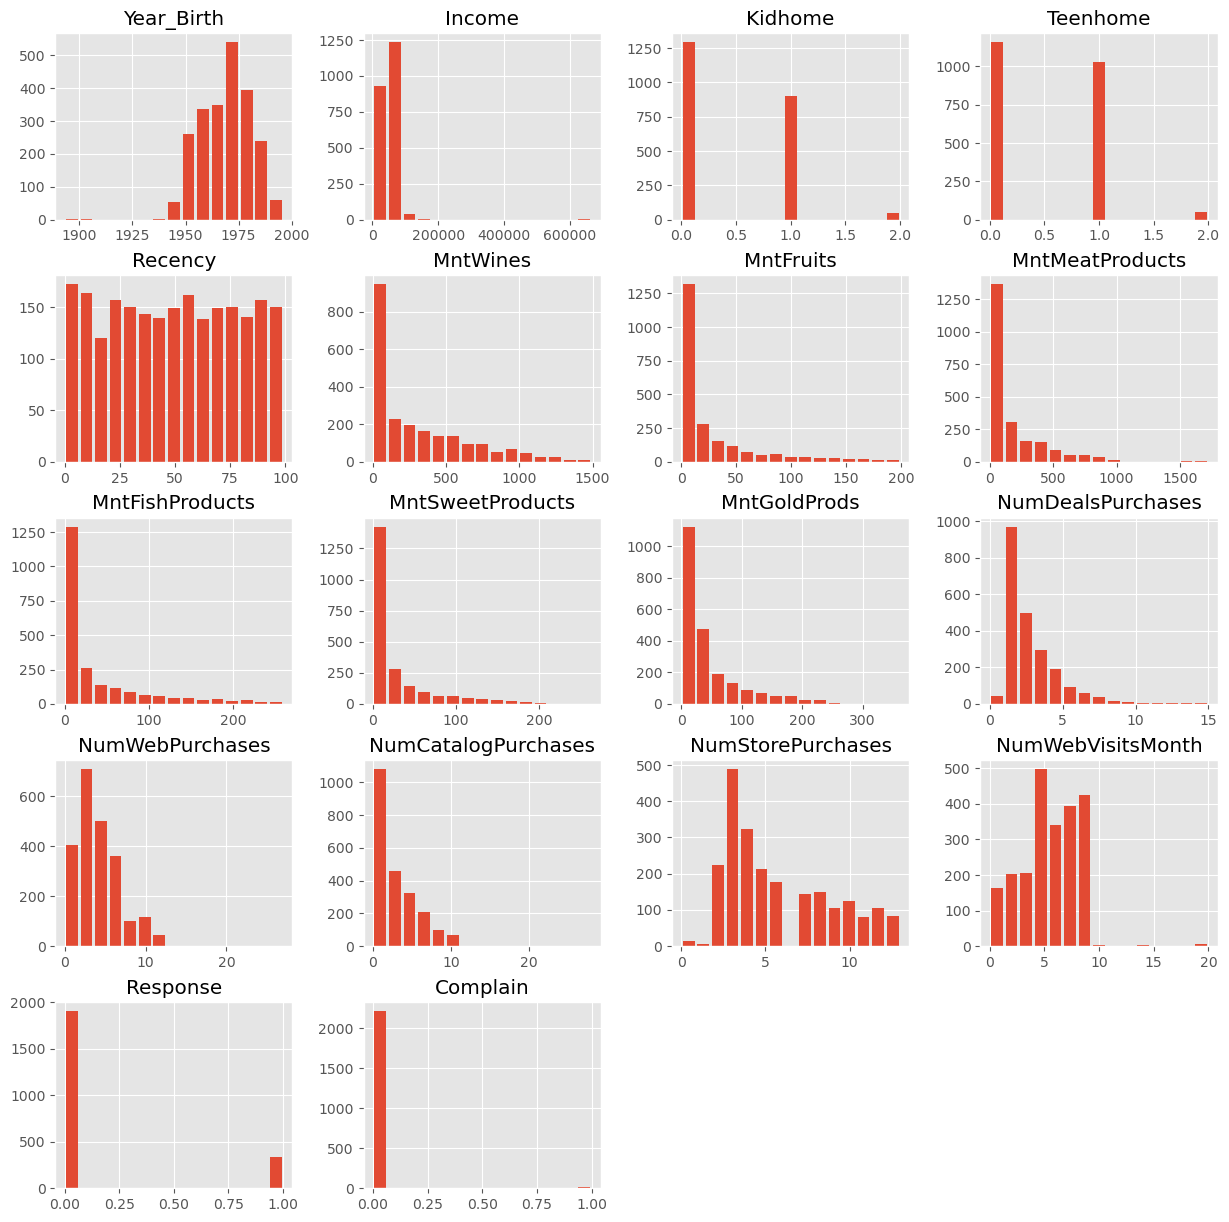

In [11]:
data.hist(figsize=(15, 15), bins=15, rwidth=0.8)
plt.show()

In [12]:
data = data.dropna()
data.info()

<class 'pandas.DataFrame'>
Index: 2216 entries, 1826 to 4070
Data columns (total 21 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Year_Birth           2216 non-null   int64  
 1   Education            2216 non-null   str    
 2   Marital_Status       2216 non-null   str    
 3   Income               2216 non-null   float64
 4   Kidhome              2216 non-null   int64  
 5   Teenhome             2216 non-null   int64  
 6   Dt_Customer          2216 non-null   str    
 7   Recency              2216 non-null   int64  
 8   MntWines             2216 non-null   int64  
 9   MntFruits            2216 non-null   int64  
 10  MntMeatProducts      2216 non-null   int64  
 11  MntFishProducts      2216 non-null   int64  
 12  MntSweetProducts     2216 non-null   int64  
 13  MntGoldProds         2216 non-null   int64  
 14  NumDealsPurchases    2216 non-null   int64  
 15  NumWebPurchases      2216 non-null   int64  
 16  N

#### Data cleaning
Some values appear weird, for instance in the column `Year_Birth`. In addition, we might want to remove some "outliers", i.e., rare cases in which we might not be so interested. Here, this could be the few people with enormously high incomes (independent of whether those values are true or not...).

In [13]:
mask = (data["Income"] < 150000) & (data["Year_Birth"] >= 1925)
data = data[mask]
data.head()

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Response,Complain
Id,,,,,,,,,,,,,,,,,,,,,
1826,1970,Graduation,Divorced,84835.0,0,0,6/16/2014,0,189,104,...,111,189,218,1,4,4,6,1,1,0
1,1961,Graduation,Single,57091.0,0,0,6/15/2014,0,464,5,...,7,0,37,1,7,3,7,5,1,0
10476,1958,Graduation,Married,67267.0,0,1,5/13/2014,0,134,11,...,15,2,30,1,3,2,5,2,0,0
1386,1967,Graduation,Together,32474.0,1,1,11/5/2014,0,10,0,...,0,0,0,1,1,0,2,7,0,0
5371,1989,Graduation,Single,21474.0,1,0,8/4/2014,0,6,16,...,11,0,34,2,3,1,2,7,1,0


Here, we also use some **feature manipulation** to change features into a easier-to-interpret form (age) or to compute additional quantities that we expect to be relevant.

In [14]:
#Age of customer compared to (approximate) data of the dataset - 2020
data["Age"] = 2020 - data["Year_Birth"]

#Total spendings on various items
data["Spent"] = data.iloc[:, 8:14].sum(axis=1)

#Dropping some of the redundant features
to_drop = ["Year_Birth"]
data = data.drop(to_drop, axis=1)

#### Data processing

Dimensionality reduction techniques such as PCA require numerical data, which makes sense if we look at how the method works (see above).
The most common pitfall, however, is that **PCA is extremely sensitive to the scaling of the data**. It looks for the features with the largest variance, so imagine that one feature is income, which can have values of many 10,000s, and another feature is age, which will usually stay below 100. Then PCA will virtually ignore the feature "age" in comparison to the much higher values of the feature "income". To circumvent this undesirable effect, the data needs to be **scaled so that all features show comparable ranges**.

Here, we will use the Scikit-Learn `StandardScaler` for this task.

In [15]:
from sklearn.preprocessing import StandardScaler

# Creating a copy of data (with only numerical values)
data_numerical = data.copy().select_dtypes(include='number')

# Creating a subset of dataframe by dropping the features on deals accepted and promotions
cols_remove = ["Complain", "Response"]
data_numerical = data_numerical.drop(cols_remove, axis=1)

# Scaling
scaler = StandardScaler()
scaler.fit(data_numerical)
data_scaled = pd.DataFrame(scaler.transform(data_numerical),
                           columns= data_numerical.columns )

In [16]:
data_scaled.head()

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Age,Spent
0,1.603840,-0.823405,-0.930767,-1.694318,-0.347240,1.950872,0.981413,1.336263,3.936458,3.362873,-0.699147,-0.036788,0.484147,0.054432,-1.797341,-0.093624,0.969477
1,0.264092,-0.823405,-0.930767,-1.694318,0.467775,-0.538100,-0.465299,-0.561124,-0.659718,-0.136437,-0.699147,1.059382,0.126750,0.362973,-0.139645,0.675400,-0.049576
2,0.755487,-0.823405,0.906602,-1.694318,-0.510242,-0.387253,-0.488263,-0.415171,-0.611081,-0.271770,-0.699147,-0.402177,-0.230646,-0.254109,-1.382917,0.931742,-0.591519
3,-0.924655,1.038757,0.906602,-1.694318,-0.877740,-0.663806,-0.754642,-0.688833,-0.659718,-0.851766,-0.699147,-1.132957,-0.945440,-1.179732,0.689203,0.162718,-0.990496
4,-1.455841,1.038757,-0.930767,-1.694318,-0.889595,-0.261548,-0.649009,-0.488148,-0.659718,-0.194437,-0.168834,-0.402177,-0.588043,-1.179732,0.689203,-1.717119,-0.857504


Finally, we can compute the PCA components for our data:

In [17]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2).fit(data_scaled)
X_pca = pca.transform(data_scaled)
X_pca.shape

(2205, 2)

As we see, the data (2205 datapoints) is now reduced to two dimensions. We will use these two dimensions to plot all datapoints using a scatter plot.

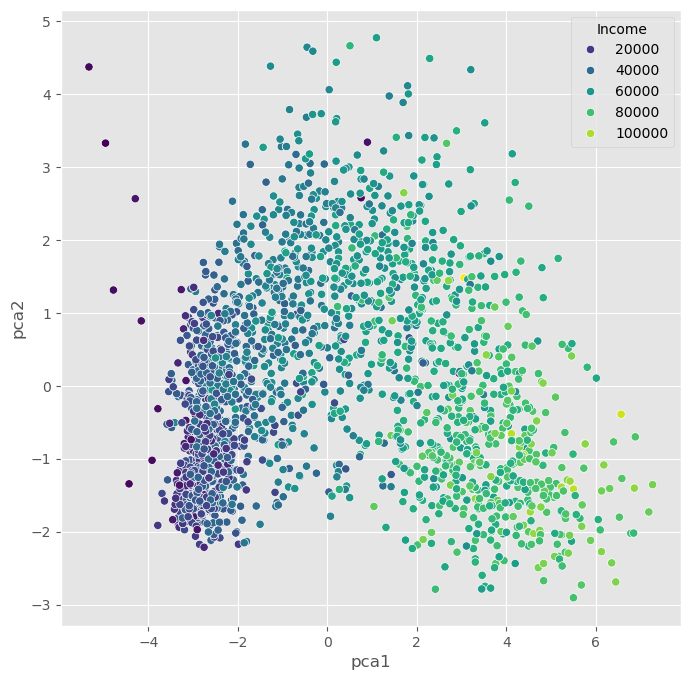

In [18]:
import seaborn as sb

data_plot = data.copy()
data_plot[["pca1", "pca2"]] = X_pca

fig, ax = plt.subplots(figsize=(8, 8))
sb.scatterplot(data=data_plot,
                x="pca1",
                y="pca2",
                hue="Income",
                palette="viridis")
plt.show()

We can, obviously, freely choose which feature we want to use for coloring. It is also possible to add another feature for scaling the size of the dots.

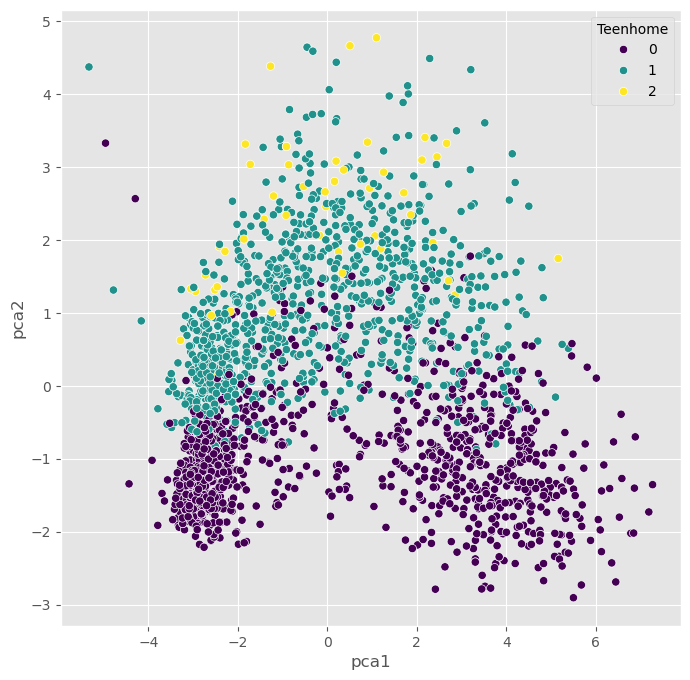

In [19]:
fig, ax = plt.subplots(figsize=(8, 8))
sb.scatterplot(data=data_plot,
                x="pca1",
                y="pca2",
                hue="Teenhome",
                palette="viridis")
plt.show()

### Non-linear Projections

The PCA plots above show that the dimensionality reduction worked to some extent. How do we know this? Well, first we see that the points are not randomly distributed without any visible correlation to their features. We see that high- and low-income people are placed in different areas of the plot, and the same is true for other features as well.

Still, in many cases, PCA might not provide the best possible results. Mostly because of its main limitation: being a linear method. This can be seen particularly well in the plot, which uses the income for the dot color. This clearly shows a clear overall direction from low to high incomes.

**Why is this a problem?**  
A lot of data we care about is highly non-linear. And linear methods are then often not able to map the data onto fewer dimensions in an appropriate or sufficiently delicate & complex manner. In the present case, we might get the impression that the plot -while it looks nice- may not tell us a lot of new things about our data.

In such cases, it is recommended to also try non-linear approaches. First, we will stay with the projection-based methods and have a look at PCA variants that can handle non-linearity to some extent, such as **kernel-PCA**.

### PCA on generated 2D test data
We will now test a few methods with strongly non-linear generated 2D data to better understand what the above mentioned limitation means.

In [20]:
# Generate fake data
np.random.seed(0)
r = np.concatenate((np.random.normal(1, 0.1, 200),
                    np.random.normal(0, 0.3, 100)))
phi = 100 * np.random.random(300)
x = r * np.cos(phi)
y = r * np.sin(phi)

labels = np.array(200*["crimson"] + 100*["teal"])
gen_data = np.stack((x/np.max(x), y/np.max(y)))

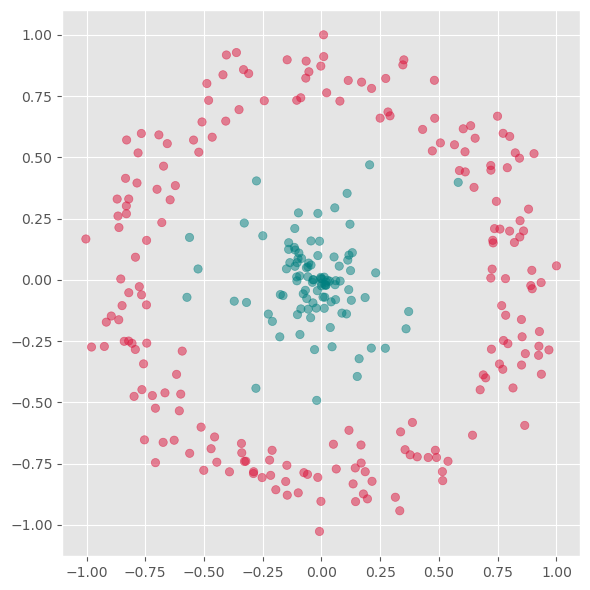

In [21]:
fig, ax = plt.subplots(figsize=(6 ,6))
ax.scatter(gen_data[0], gen_data[1], alpha=0.5, c=labels)
plt.grid(True)
plt.tight_layout()
plt.show()

First we will apply **PCA** to reduce this data to one dimension.

In [22]:
from sklearn.decomposition import PCA

pca = PCA(n_components=1)
X_pca = pca.fit_transform(gen_data.T)

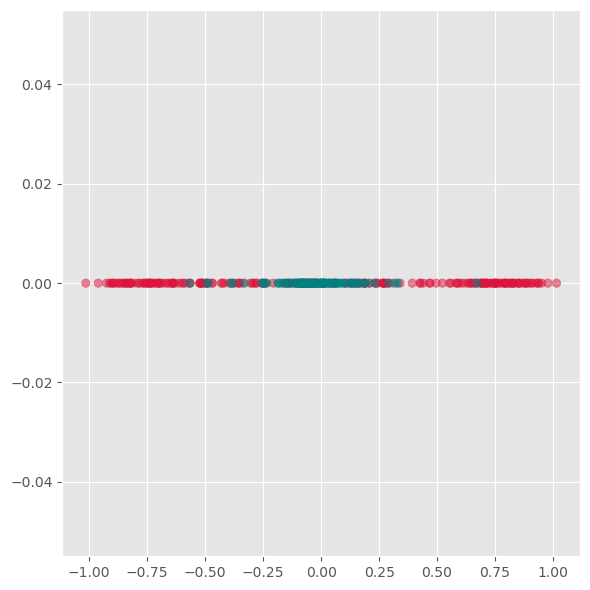

In [23]:
fig, ax = plt.subplots(figsize=(6 ,6))
ax.scatter(X_pca, np.zeros(300), alpha=0.5, c=labels)
plt.grid(True)
plt.tight_layout()
plt.show()

As we see from this plot, **PCA** is not able to separate the two different colors. This means it does not find a good lower-dimensional representation of this particular dataset.

Its inability to handle non-linearity is the main limitation of PCA. For many applications, in particular data visualization, this is a very strong limitation and the reason why other techniques have often taken its place.


### Kernel-PCA

Kernel-PCA processes data in a higher-dimensional space, a technique often referred to as the "kernel trick." A commonly used kernel function in this context is the Radial Basis Function (RBF).

Initially, this approach might seem counterintuitive. The objective of dimensionality reduction is to simplify data, so why first move it into a higher-dimensional space? The purpose of this step is to overcome the limitations of linear transformations, such as the principal axis transformation or rotation, found in PCA. By implicitly mapping the data into a higher-dimensional feature space, Kernel PCA can sometimes uncover structure that ordinary linear PCA cannot capture.  
In practice, Kernel PCA is often useful as a conceptual bridge between linear PCA and more flexible manifold-learning methods.

**Advantages:**

- A non-linear technique, capable of handling non-linear data.
- Still relatively fast compared to other non-linear methods.

**Disadvantages:**

- Requires optimization of additional parameters, such as the choice of kernel function and its parameters.
- These parameters can significantly impact the results, making the process sensitive to these settings.

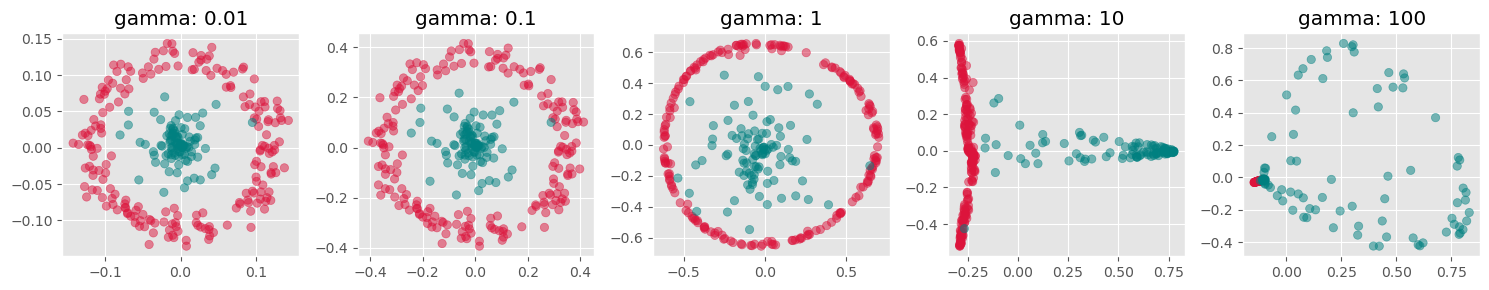

In [24]:
from sklearn.decomposition import KernelPCA

fig, axs = plt.subplots(1, 5, figsize=(15 ,3))

for i, gamma in enumerate([0.01, 0.1, 1, 10, 100]):
    kpca = KernelPCA(n_components=2, kernel="rbf",
                     gamma=gamma, random_state=42,
                     fit_inverse_transform=True, alpha=0.1)

    X_kpca = kpca.fit_transform(gen_data.T)

    axs[i].scatter(X_kpca[:, 0], X_kpca[:, 1], alpha=0.5, c=labels)
    axs[i].set_title(f"gamma: {gamma}")
    axs[i].grid(True)

plt.tight_layout()
plt.show()

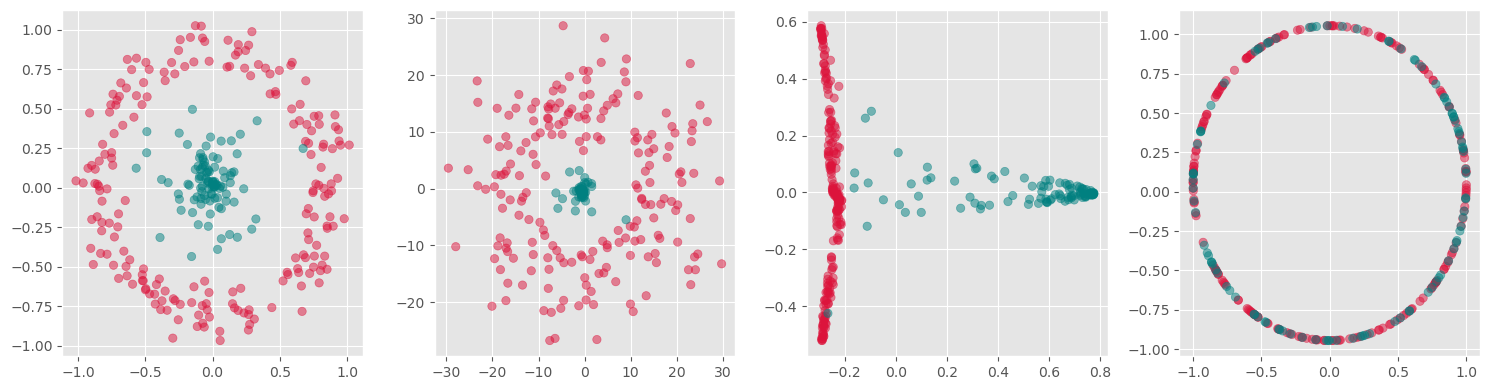

In [25]:
fig, axs = plt.subplots(1, 4, figsize=(15 ,4))

for i, kernel in enumerate(["linear", "poly", "rbf", "cosine"]):
    kpca = KernelPCA(n_components=2, kernel=kernel,
                     gamma=10, random_state=42,
                     fit_inverse_transform=True, alpha=0.1)

    X_kpca = kpca.fit_transform(gen_data.T)

    axs[i].scatter(X_kpca[:, 0], X_kpca[:, 1], alpha=0.5, c=labels)
    axs[i].grid(True)

plt.tight_layout()
plt.show()

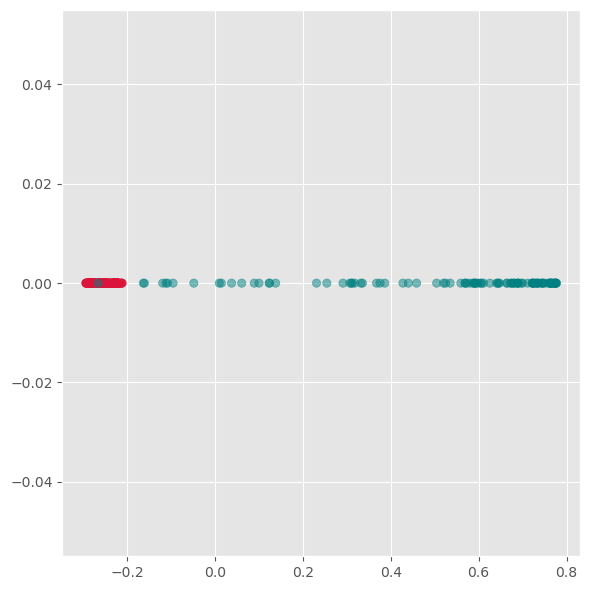

In [26]:
kpca = KernelPCA(n_components=1, kernel='rbf', 
                 gamma=10, random_state=42)
X_kpca = kpca.fit_transform(gen_data.T)

fig, ax = plt.subplots(figsize=(6 ,6))
ax.scatter(X_kpca, np.zeros(300), alpha=0.5, c=labels)
ax.grid(True)
plt.tight_layout()
plt.show()

Here we see, that kernel-PCA is capable of keeping the two colors separate even after reducing all points to one dimension.

## Feature Extraction 2: Manifold Learning

Manifold Learning is a class of techniques designed for discovering the underlying structure or manifold of high-dimensional data. Unlike linear methods that attempt to preserve global linear relationships, manifold learning focuses on uncovering local structures, ideally capturing the intrinsic geometry of the data (see {numref}`fig_manifolds`). The central assumption of manifold learning is that the data of interest lies on an embedded non-linear manifold within the higher-dimensional space. By understanding this manifold, one can reduce the dimensionality while preserving the data's essential characteristics, which is particularly useful for complex datasets where linear projections like PCA fall short.

```{figure} ../images/fig_dimensionality_reduction_manifolds.png
:name: fig_manifolds

Linear projections of highly non-linear data onto fewer dimensions are often far from ideal (left). A central goal in manifold learning is to find geometries that better represent the intrinsic structure of the data (right) thereby leading to much better dimensionality reduction results.
```

### t-SNE

t-SNE, introduced by Maaten and Hinton in 2008, is a sophisticated technique that has rapidly gained popularity for its effectiveness in visualizing and reducing the dimensions of data that reside on complex manifolds {cite}maaten2008tsne. Unlike PCA, t-SNE is particularly suited for embedding high-dimensional data into a space of two or three dimensions, which makes it an excellent tool for visualizing data clusters.

**Advantages:**

- **Handling Non-Linearity**: t-SNE excels in managing non-linear relationships in data, making it ideal for datasets where the underlying structure is intricate.
- **Superior Visualization**: It produces visually appealing results that highlight clusters and structures that are not apparent in linear dimensionality reduction outputs.

**Disadvantages:**

- **Computational Intensity**: The technique is computationally intensive, particularly as the size of the dataset increases, making it less scalable than some linear methods.
- **Parameter Sensitivity**: t-SNE involves several hyperparameters such as the perplexity and learning rate, which require careful tuning to get meaningful results. The outcome of t-SNE can vary significantly with different settings of these parameters.

**How t-SNE Works:**

- **Probability Distributions**: t-SNE converts the distances between data points in high-dimensional space into conditional probabilities that represent similarities. The similarity of datapoint xjxj to datapoint xixi is the conditional probability that xixi would pick xjxj as its neighbor if neighbors were picked in proportion to their probability density under a Gaussian centered at xixi.
- **KL Divergence Minimization**: In the low-dimensional space, t-SNE similarly creates a probability distribution using a Student's t-distribution to model the similarity between points. The optimization objective is to minimize the Kullback–Leibler divergence between the two distributions over the positions of points in the low-dimensional space. This divergence measures how much one probability distribution differs from a second, reference probability distribution.

**Practical Considerations:**

- **Data Scaling**: Similar to PCA, data should be scaled (standardized) before applying t-SNE to ensure that all features contribute equally.
- **Dimensionality Curse**: Although t-SNE is designed for high-dimensional data, excessively high dimensions can degrade its performance, often necessitating the use of an initial dimensionality reduction method like PCA before applying t-SNE.

By focusing on local rather than global relationships, t-SNE can uncover intricate patterns in the data, making it highly suitable for exploratory data analysis and data visualization in tasks where understanding the data's grouping and structure is crucial.

C:\Users\flori\anaconda3\envs\data_science\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


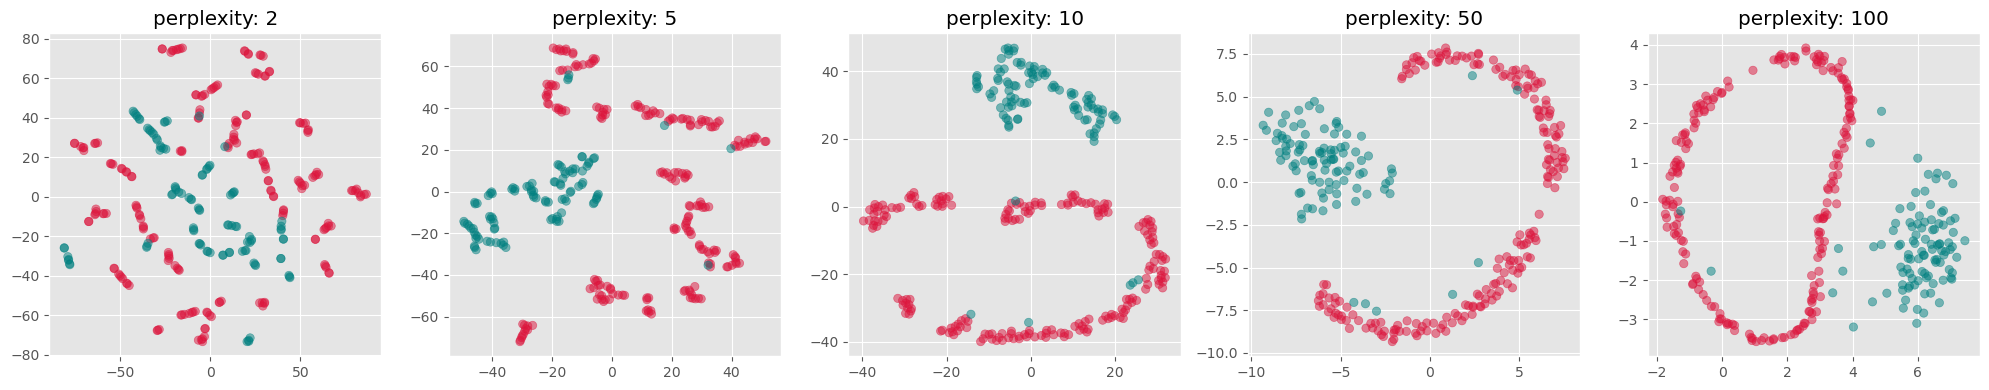

In [27]:
from sklearn.manifold import TSNE

perplexities = [2, 5, 10, 50, 100]
fig, axs = plt.subplots(1, len(perplexities), figsize=(4*len(perplexities) ,4))

for i, perplexity in enumerate(perplexities):
    tsne = TSNE(n_components=2, perplexity=perplexity, init="random")
    X_tsne = tsne.fit_transform(gen_data.T)

    axs[i].scatter(X_tsne[:, 0], X_tsne[:, 1], alpha=0.5, c=labels)
    axs[i].set_title(f"perplexity: {perplexity}")
    axs[i].grid(True)

plt.tight_layout()
plt.show()

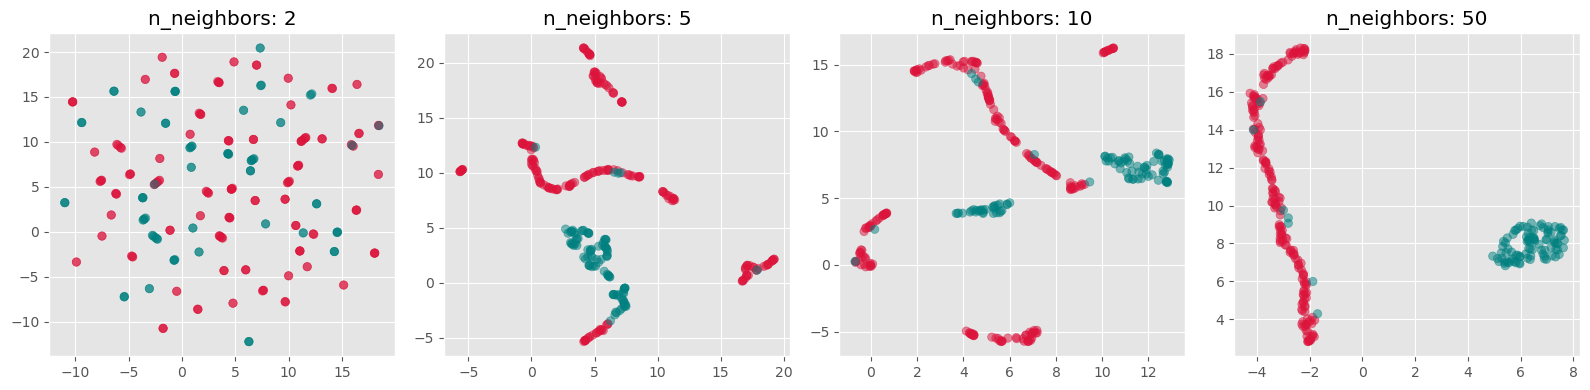

In [28]:
import umap

n_neighbors_values = [2, 5, 10, 50]
fig, axs = plt.subplots(1, len(n_neighbors_values), figsize=(4 * len(n_neighbors_values), 4))

for i, n_neighbors in enumerate(n_neighbors_values):
    reducer = umap.UMAP(n_components=2, n_neighbors=n_neighbors, init="random")
    X_umap = reducer.fit_transform(gen_data.T)

    axs[i].scatter(X_umap[:, 0], X_umap[:, 1], alpha=0.5, c=labels)
    axs[i].set_title(f"n_neighbors: {n_neighbors}")
    axs[i].grid(True)

plt.tight_layout()
plt.show()

In [ ]:
### Comparison and Application

Each of these techniques has unique strengths and weaknesses, making them suitable for different types of data and objectives. Kernel-PCA is a versatile tool for moderately complex data, while t-SNE and UMAP excel at revealing intricate structures in high-dimensional data.

The choice of technique depends on the specific requirements of the analysis, such as the need for speed (favoring Kernel-PCA), detail (favoring t-SNE), or a balance of structure preservation and speed (favoring UMAP). Understanding the nature of the dataset and the goals of the analysis is key to selecting the most appropriate dimensionality reduction method. 

For even more techniques, see for instance {cite}`anowar2021conceptual` or {cite}`wang2021dimensionreduction`.

### Use case: Marketing Analysis (t-SNE)
Let us now continue with our use case of the marketing dataset. Before we used PCA which did work to some extent, but maybe not as well as we wanted. Let's compare this to using t-SNE for reducing the datapoints to only two dimensions so that we can visualize all data points in a 2D scatter plot.

In [37]:
from sklearn.manifold import TSNE

tsne = TSNE(perplexity=50,
           random_state=0)
X_tsne = tsne.fit_transform(data_scaled)

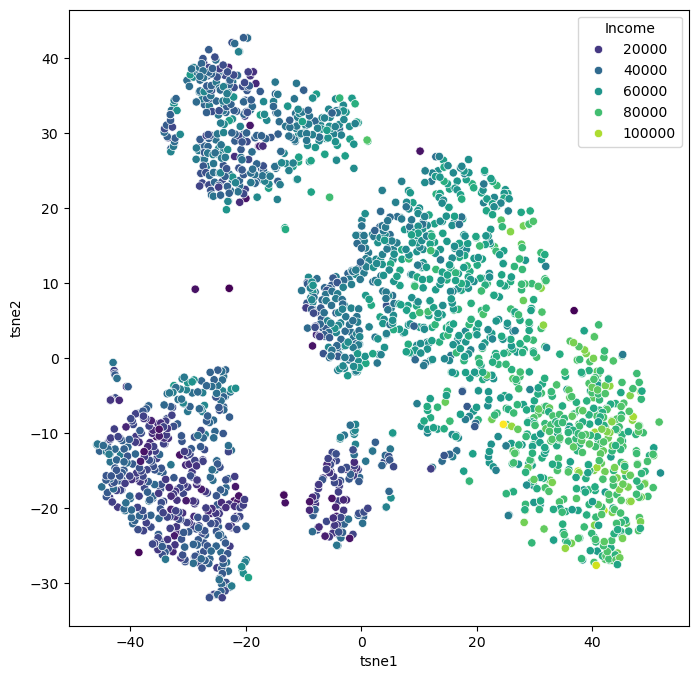

In [38]:
data_plot[["tsne1", "tsne2"]] = X_tsne


fig, ax = plt.subplots(figsize=(8, 8))
sb.scatterplot(data=data_plot,
                x="tsne1",
                y="tsne2",
                hue="Income",
                palette="viridis")
plt.show()

We can of course, also plot several features in parallel by combining multiple plots.

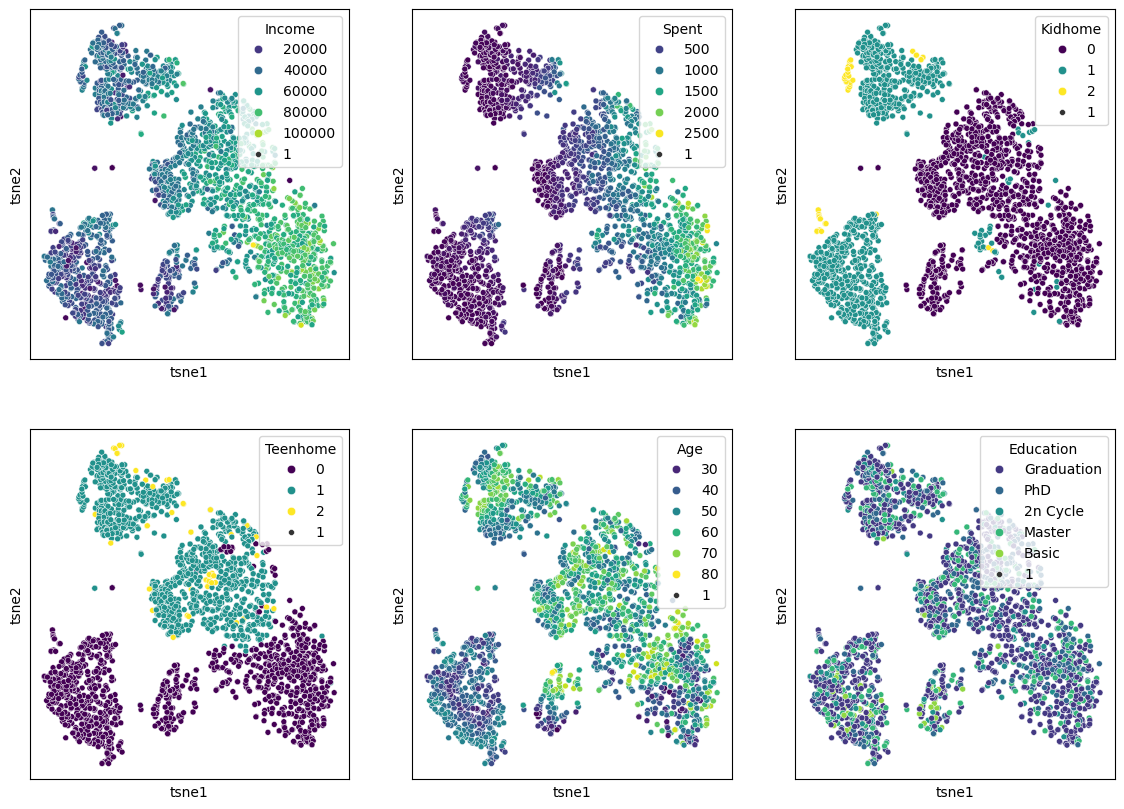

In [40]:
features = ["Income", "Spent", "Kidhome", "Teenhome", "Age", "Education"]

fig, axes = plt.subplots(2, 3, figsize=(14, 10))

for i, ax in enumerate(axes.reshape(-1)):
    sb.scatterplot(data=data_plot,
                   x="tsne1",
                   y="tsne2",
                   hue=features[i],
                   palette="viridis",
                   ax=ax)
    
    ax.set_xticks(ticks=[])
    ax.set_yticks(ticks=[])
plt.show()

When we compare this result to the PCA results from before, it becomes clear that t-SNE is clearly able to draw a much more nuanced picture of our data. We will explore some more techniques in the "More on dimensionality reduction" part below, but for a first general picture, we could stop here and conclude:

- **Dimensionality** reduction techniques are extremely powerful for exploring complex and larger datasets.
- **PCA** is a standard technique every data scientist should know about. It also has many other use cases beyond data visualization, but we will come to that in later chapters.
- Current de facto standards in many data science processes are non-linear manifold-learning techniques such as **t-SNE** or **UMAP**. Those are more difficult to fully understand algorithmically, but they typically deliver better data representations than PCA.

## More on dimensionality reduction

**t-SNE** was an extremely important milestone in the field of data science. In many applications, however, it has recently been succeeded by other manifold-learning techniques, most notably **UMAP**. Later in this subsection, we will discuss general limitations of all those techniques, and we will mention other techniques and provide starting points for those eager to dive deeper into the matter of dimensionality reduction.

### UMAP (Uniform Manifold Approximation and Projection)

UMAP is a relatively recent addition to dimensionality reduction techniques {cite}`mcinnes2018umap`. Like t-SNE, UMAP is especially popular for visualization. In practice, it is often faster than t-SNE and sometimes preserves more global structure, although this depends strongly on the data and parameter choices.

The central assumption behind UMAP is similar to that of other manifold-learning methods: although the data may live in a very high-dimensional space, its actually relevant structure might lie on a lower-dimensional manifold. The task is then to find a low-dimensional representation that keeps as much of this structure as possible.

### A brief sketch of how UMAP works

UMAP is mathematically quite sophisticated, but the main idea can be sketched in a fairly intuitive way.

First, UMAP builds a graph of the data by connecting each point to its nearest neighbors. In this step, the method tries to capture the **local structure** of the data: which points are close to each other and how strongly they appear to be connected.

Second, UMAP interprets this graph in a probabilistic or weighted way. Rather than saying simply *“these two points are neighbors”* or *“they are not”*, it assigns strengths to these neighborhood relations. In this way, the high-dimensional dataset is represented as a kind of weighted network.

Third, UMAP searches for a low-dimensional arrangement of the points—usually in 2D or 3D—such that points that were strongly connected in the original high-dimensional graph stay close together, while weakly connected or disconnected points are allowed to lie farther apart.

So, in very rough terms, UMAP works by:

1. building a neighborhood graph in the original space,
2. turning this into a weighted representation of local relationships,
3. and then optimizing a low-dimensional layout that preserves as much of that neighborhood structure as possible.

This may sound somewhat similar to t-SNE, and indeed both methods try to preserve neighborhood relations. But UMAP usually places more emphasis on maintaining a meaningful overall arrangement of the data and is often computationally more efficient.

### Important parameters

Just like t-SNE, UMAP has parameters that can strongly influence the result. Two of the most important ones are:

* **`n_neighbors`**: controls how strongly UMAP focuses on very local versus somewhat broader structure. Smaller values emphasize local neighborhoods more strongly, while larger values tend to preserve more global structure.
* **`min_dist`**: controls how tightly points are allowed to pack together in the low-dimensional embedding. Small values often produce more compact, visually separated clusters, while larger values lead to smoother and more spread-out layouts.

This means that UMAP, just like t-SNE, is not a push-button method where one single default setting is always ideal.

**Advantages:**

* Efficient with large datasets.
* Often faster than t-SNE (in particular when we use newer GPU-based implementations such as in `cuml`, [see rapids.ai documentation](https://docs.rapids.ai/api/cuml/stable/) !)
* Can preserve both local structure and, in many cases, more of the global structure than t-SNE.
* Flexible and widely used for exploratory data analysis and visualization.

**Disadvantages:**

* Like other non-linear methods, it requires parameter tuning.
* The results can be sensitive to these parameter choices.
* Just like t-SNE, the resulting 2D or 3D embedding should not be interpreted as a perfect map of the original high-dimensional relationships.

### Practical note

In practice, UMAP has become a very popular choice for visualizing high-dimensional data, especially in areas such as bioinformatics, image analysis, and text embeddings. Many people prefer it over t-SNE because it is often faster, often scales better to larger datasets, and frequently produces layouts that are easier to interpret across repeated runs.

Still, it is important to keep in mind that UMAP is primarily a tool for **exploration and visualization**. A beautiful 2D UMAP plot is not a proof that the underlying data really consists of clearly separated groups. It is always a reduced representation, and therefore always a simplification.

### Exercise
Both t-SNE and UMAP currently see widespread use. Neither of them is always better or worse. And often, it appears, it is also a matter of personal preference.

- Re-run the above dimensionality reduction but use UMAP instead of t-SNE
- Explore different settings for the parameter `n_neighbors`
- Which one do you prefer, t-SNE or UMAP? And why is that?
- What made you intuitively decide which `n_neighbors` setting is best?

## More than just t-SNE and UMAP

Even though **t-SNE** and **UMAP** are currently among the most widely used techniques for non-linear dimensionality reduction and visualization, they are by no means the only available methods.

One further method that has received considerable attention is **PaCMAP** (*Pairwise Controlled Manifold Approximation*), which was developed with the goal of balancing the preservation of local and more global structure in the low-dimensional embedding {cite}`wang2021dimensionreduction`. Just like t-SNE and UMAP, it aims to create useful 2D or 3D visualizations of complex high-dimensional data, but it does so with a somewhat different optimization strategy.

And beyond these manifold-learning methods, there is yet another broad route to visualizing complex data: instead of reducing the data directly into 2D coordinates, one can first represent the data as a **graph** or **network** and then visualize that graph using a layout algorithm. In such approaches, data points become nodes and relationships or similarities become edges. This can be especially useful when pairwise relationships matter more than exact geometric positions. We will come back to this later in {numref}`ch-graph-visualization`.

So, even within the specific task of displaying complex data in two or three dimensions, there is a whole toolbox of possible approaches. The methods covered in this chapter are important and widely used, but they are only a small selection.

## Limitations of dimensionality reduction
Dimensionality reduction can be an extremely powerful tool in data science. It can help us better understand data, simplify later analyses, and communicate patterns in a more accessible way. Large and complex datasets often become far more approachable once we can inspect them in a 2D scatter plot or a similar visual representation.

However, all of this comes with an important limitation: **dimensionality reduction nearly always implies information loss**.

This is not a small technical inconvenience but a fundamental fact. A high-dimensional dataset simply contains relationships that cannot all be represented faithfully in only two or three dimensions. This can be understood with the simple geometric example shown in {numref}`fig_dimensionality_reduction_limits`, so we could say that 2D is *too small* for that purpose.

```{figure} ../images/fig_dimensionality_reduction_limits.png
:name: fig_dimensionality_reduction_limits

In virtually all cases, dimensionality reduction goes along with a loss of information. This can intuitively be understood by looking at the example shown here: a case where 4 data points are all equally far from each other can be represented easily in 3D (a tetrahedron). In 2D, however, such a situation is not possible. We could say that 2D is simply *too small* to display this configuration. In practice, the same will happen when projecting even higher-dimensional data into 3D, 2D, or 1D.
```
As a consequence, no matter which technique we choose, and no matter how carefully we tune its parameters, we usually do **not** end up with a perfect representation of the original data. In particular, we cannot expect that:

* all similar points in high dimensions will always appear close together in the reduced plot,
* all distant points will remain far apart,
* or all visible groups in the embedding correspond to genuinely separated groups in the original data.

This is not because the methods are poorly designed. It is because a low-dimensional embedding is always a **simplification** of a more complex structure.

Different methods also distort the data in different ways. PCA emphasizes directions of high variance. t-SNE tends to emphasize local neighborhoods very strongly. UMAP often tries to preserve local neighborhoods while keeping more of the larger-scale structure visible. None of these perspectives is simply *the truth*. Each one is a particular view of the same data.

This is why low-dimensional embeddings should usually be interpreted as **tools for exploration**, not as definitive answers. They can reveal suggestive patterns, possible groups, and interesting structure—but these observations should usually be checked against the original features and, where appropriate, against other methods as well.

## Conclusions

What should have become clear in this chapter is that dimensionality reduction is both powerful and subtle.

On the one hand, reducing data from many dimensions to only two or three can make previously inaccessible structure visible. This is why methods such as PCA, t-SNE, and UMAP have become such important tools in modern data science. In the marketing example above, we saw that non-linear methods can reveal patterns that are much less obvious when using only linear techniques such as PCA.

On the other hand, the resulting plots are never neutral windows into the data. They are always shaped by the assumptions of the method and by the parameter choices we make. This is especially true for the non-linear methods. They often require substantial tuning, and different settings can lead to noticeably different embeddings. That raises an important practical question: what exactly do we mean by the “best” low-dimensional representation?

There is no single universally accepted answer to that question. In practice, people often try several methods and parameter settings and compare the results. That can be very useful—but it also means that one must resist the temptation to simply choose the prettiest plot or the one that fits a preferred story best.

Performance is another important factor. If the goal is a fast and robust reduction of large high-dimensional datasets, **PCA** often remains the most practical baseline method. Recent advances using GPU-acceleration for UMAP, however, make it now possible to even use UMAP on comparably large datasets, [see rapids.ai](https://docs.rapids.ai/api/cuml/stable/).


## Literature and next steps

There is much more to learn about dimensionality reduction than we could cover here.

If you want to understand more deeply why high-dimensional spaces behave so differently from low-dimensional ones, it is worth reading more on the **curse of dimensionality**, especially in relation to distance-based methods and nearest-neighbor search {cite}`marimont_nearest_1979, chavez_searching_2001`.

For a broader overview of dimensionality reduction techniques, including many methods not covered here, see for instance {cite}`anowar2021conceptual` or {cite}`wang2021dimensionreduction`.

And finally, as already mentioned above, not all useful 2D or 3D representations of complex data come from direct dimensionality reduction. Another important family of approaches is based on **graphs and network layouts**, which we will later discuss in {numref}`ch-graph-visualization`.
